# Metabolite cell-cell communication with MEBOCOST

The `ov.single.Metabolism` tutorial scores metabolism *within* each
cell. This companion tutorial asks the next question: which cell
types **exchange** metabolites? `ov.single.MetaboliteCCC` wraps
MEBOCOST to infer metabolite-mediated cell-cell communication, and
reuses the existing `ov.pl.ccc_*` communication plots.

## Part.1 The idea behind MEBOCOST

A metabolite-mediated communication event has two ends:

- a **sender** cell group that *produces* a metabolite — detected as
  high expression of that metabolite's synthesis / transport enzymes;
- a **receiver** cell group that *senses* it — high expression of a
  matching **sensor**: a cell-surface receptor, a transporter, or a
  nuclear receptor.

MEBOCOST estimates per-group metabolite abundance from the enzyme
expression, pairs it with sensor expression through a curated
metabolite-sensor database, and scores every sender → receiver event
against a **permutation null** (cell-group labels shuffled) to get a
p-value. `ov.single.MetaboliteCCC.to_comm_adata()` then reshapes the
result into a communication AnnData so the standard `ov.pl.ccc_*`
plots — built for CellPhoneDB / LIANA — apply unchanged.

In [1]:
import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part.2 Load data — the same head & neck tumour

The same 200-cell HNSC tumour demo used by the per-cell metabolism
tutorial — a microenvironment of malignant, stromal and immune cells
is exactly where metabolite cross-talk matters.

In [2]:
adata = ov.datasets.metabolism_hnsc()
adata.obsm['X_umap'] = adata.obs[['UMAP_1', 'UMAP_2']].to_numpy()
adata

🔍 Downloading data to ./data/metabolism_hnsc_200cell.h5ad
⚠️ File ./data/metabolism_hnsc_200cell.h5ad already exists


AnnData object with n_obs × n_vars = 200 × 18241
    obs: 'UMAP_1', 'UMAP_2', 'Celltype (malignancy)', 'celltype', 'Celltype (minor-lineage)', 'Celltype (original)', 'cluster', 'Site', 'Celltype', 'Patient', 'Source', 'Age', 'Gender', 'Stage', 'TNMstage'
    obsm: 'X_umap'

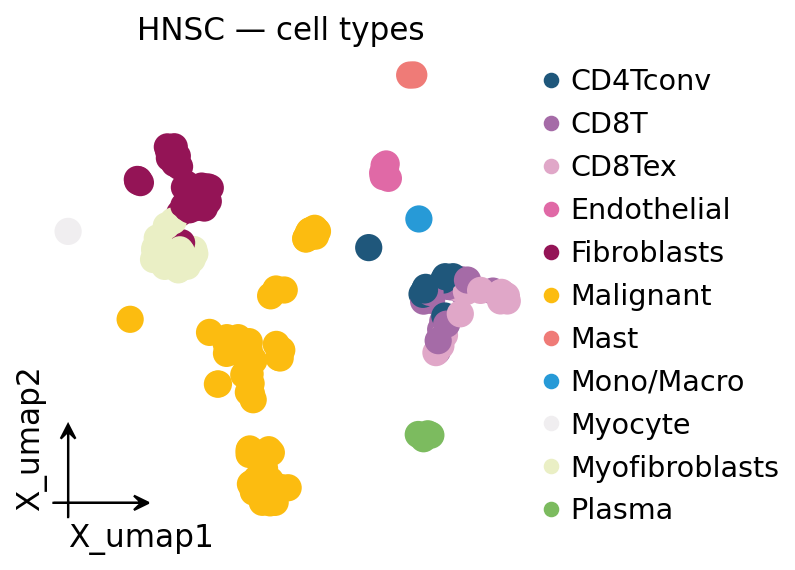

In [3]:
ov.pl.embedding(adata, basis='X_umap', color='celltype',
                frameon='small', title='HNSC — cell types')

## Part.3 Run MEBOCOST

`ov.single.MetaboliteCCC` takes the cell-group column as the unit of
communication. `run()` estimates metabolite abundance, pairs
metabolites with sensors, and runs the permutation test. `n_shuffle`
sizes the null (use ~1000 for a publication; 100 here keeps the
tutorial quick), and `min_cell_number` drops cell groups too small
to estimate from — lowered to 10 here because this is a 200-cell demo.

In [4]:
mccc = ov.single.MetaboliteCCC(adata, group_key='celltype')
mccc.run(n_shuffle=100, min_cell_number=10, verbose=False)

In [5]:
# significant metabolite -> sensor communication events
mccc.result[['Sender', 'Receiver', 'Metabolite_Name', 'Sensor',
             'Commu_Score', 'permutation_test_fdr']].head(10)

,Sender,Receiver,Metabolite_Name,Sensor,Commu_Score,permutation_test_fdr
35,Myofibroblasts,Malignant,D-Glucose,SLC2A1,0.012496,0.0
2,Fibroblasts,Malignant,gamma-Aminobutyric acid,SLC6A8,0.042131,0.0
24,Malignant,Malignant,Adenine,SLC35F5,0.149409,0.0
24,Malignant,Malignant,gamma-Aminobutyric acid,SLC6A11,0.026091,0.0
2,Fibroblasts,Malignant,gamma-Aminobutyric acid,SLC6A11,0.022441,0.0
8,Fibroblasts,CD8Tex,alpha-Linolenic acid,FFAR4,0.000719,0.0
34,Myofibroblasts,CD8T,3-Hydroxybutyric acid,SLC16A7,0.003235,0.0
2,Fibroblasts,Malignant,D-Mannose,SLC2A1,0.138227,0.0
8,Fibroblasts,CD8Tex,D-Mannose,SLC2A3,0.062002,0.0
34,Myofibroblasts,CD8T,D-Mannose,SLC2A3,0.049756,0.0


## Part.4 Reuse the cell-cell-communication plots

`to_comm_adata()` converts the MEBOCOST result into a communication
AnnData — `obs['sender']` / `obs['receiver']` plus `layers['means']`
and `layers['pvalues']` — exactly the schema the `ov.pl.ccc_*` family
consumes. No metabolite-specific plotting code is needed.

In [6]:
comm = mccc.to_comm_adata()
comm

AnnData object with n_obs × n_vars = 214 × 1
    obs: 'sender', 'receiver', 'metabolite', 'sensor', 'interaction'
    uns: 'mebocost_comm'
    layers: 'means', 'pvalues'

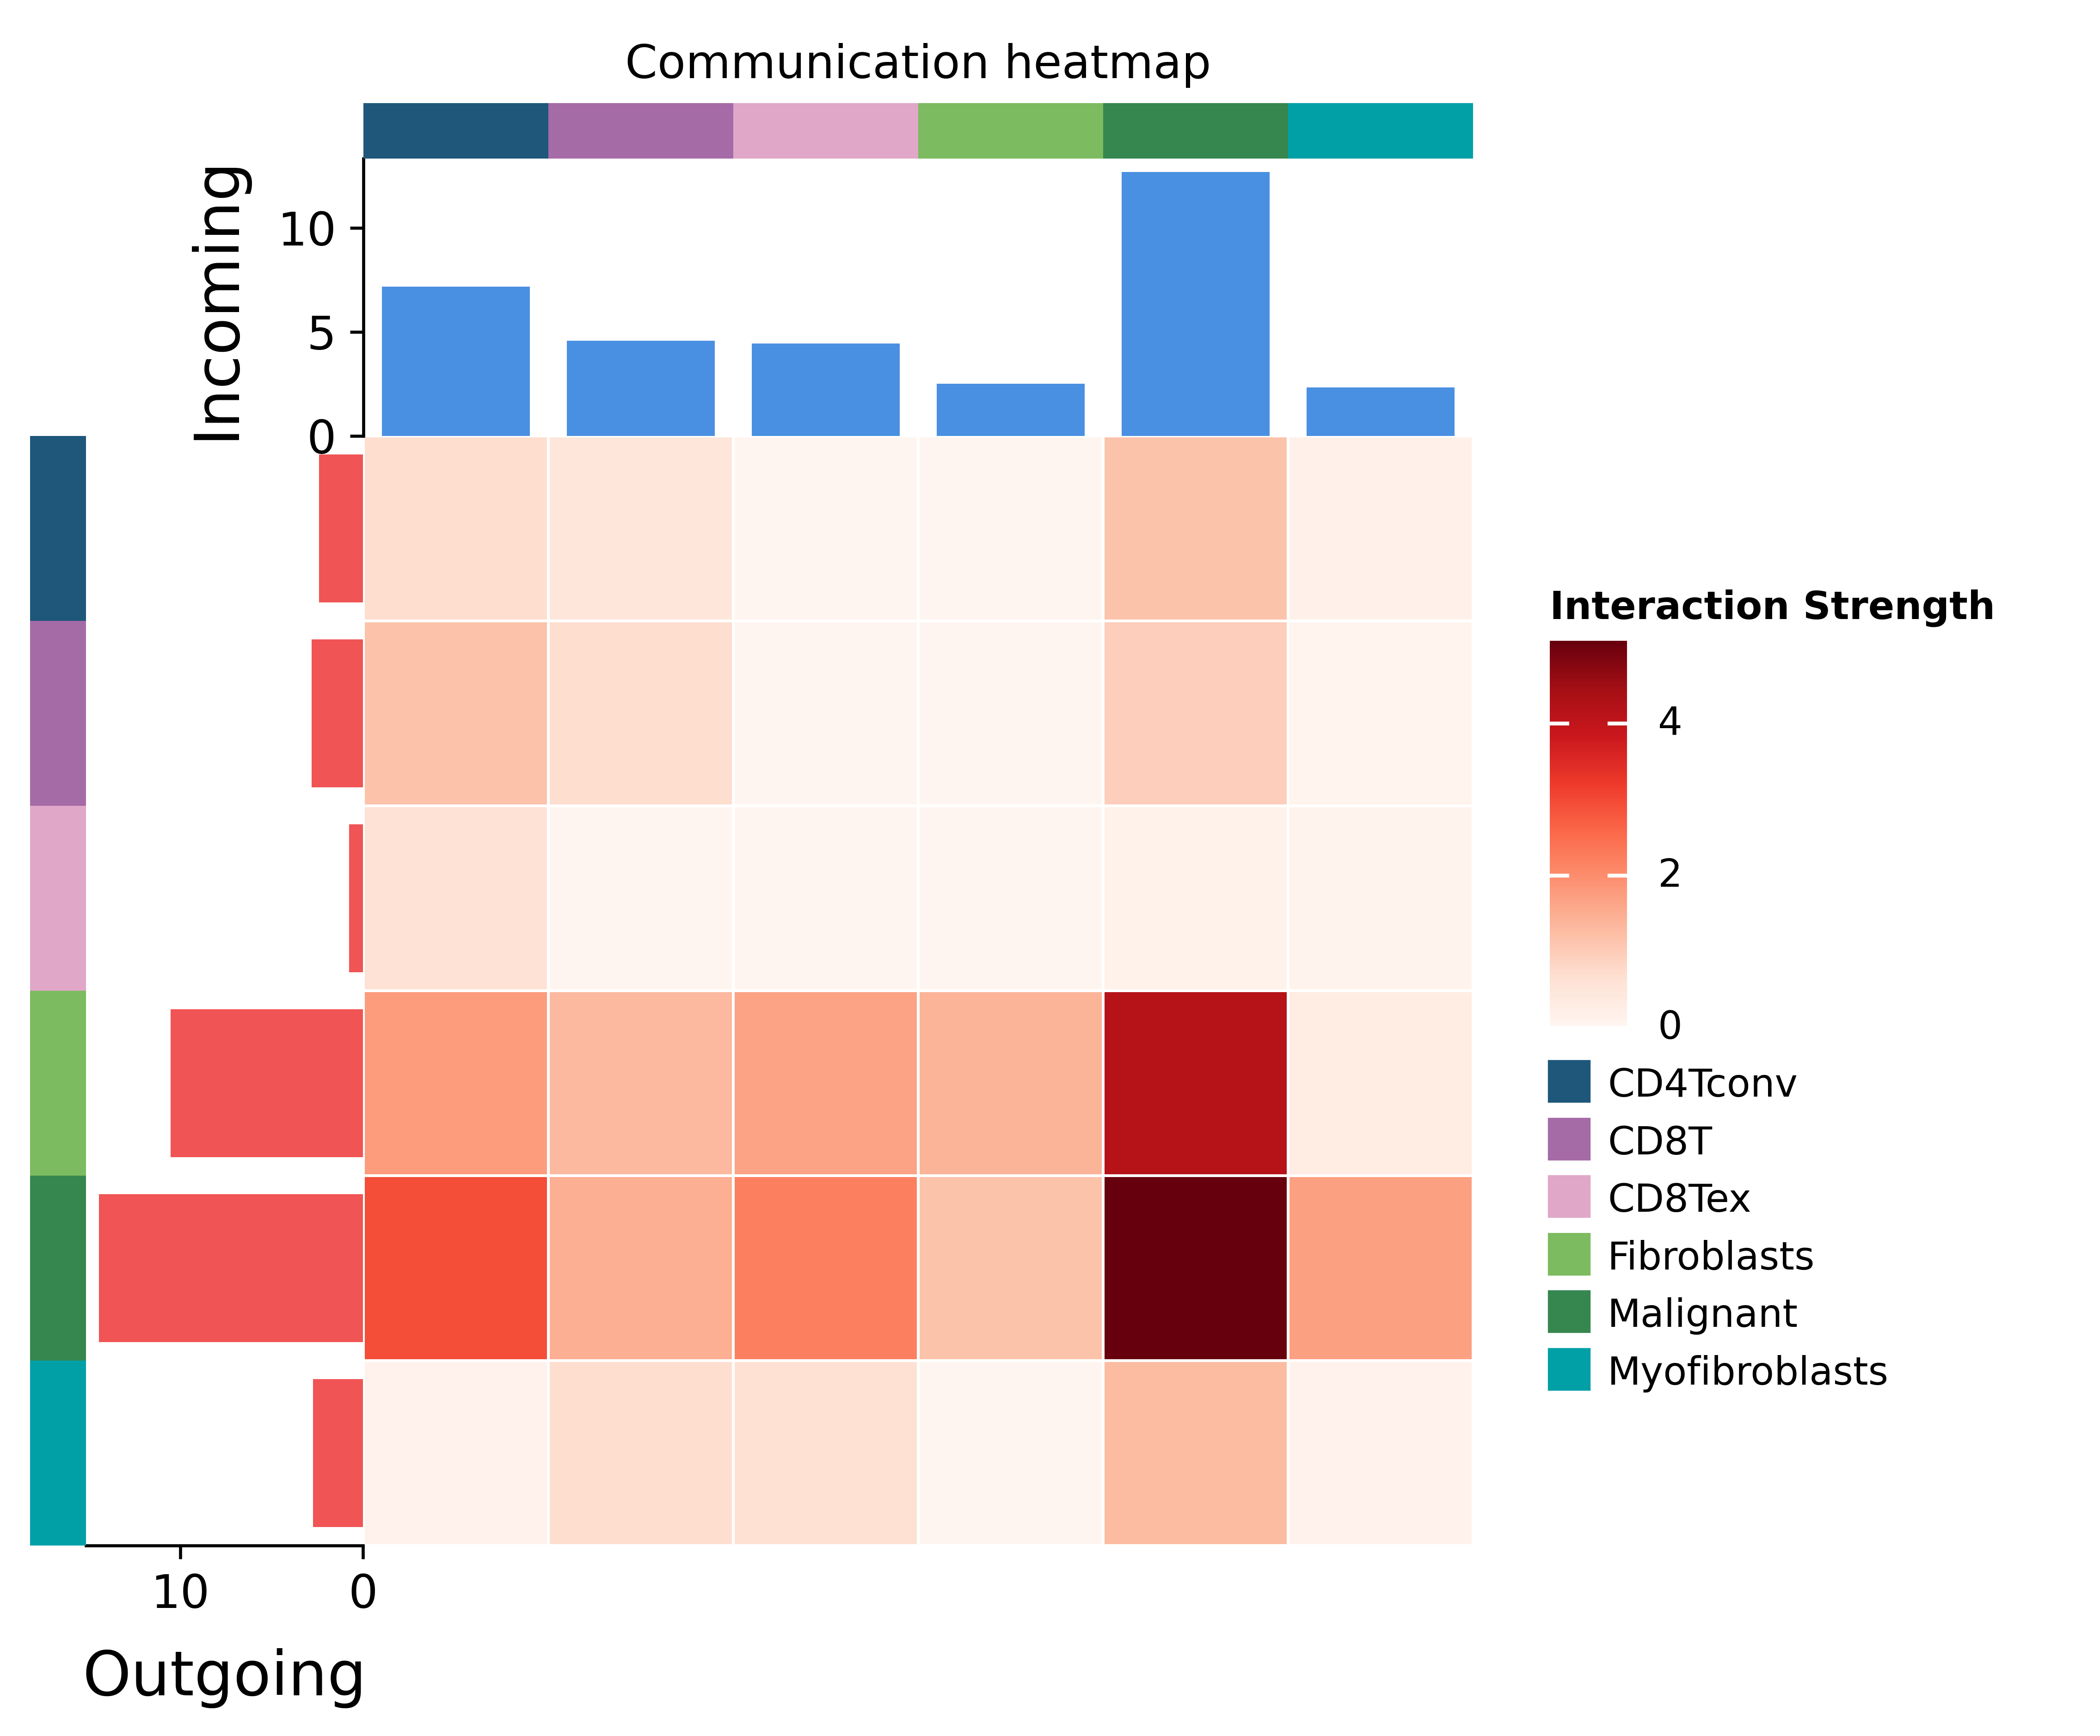

In [7]:
fig, ax = ov.pl.ccc_heatmap(comm, plot_type='heatmap')
fig

---

**Recap.** `ov.single.MetaboliteCCC` extends the metabolism module
from the single cell to the tissue: it names the metabolite ↔ sensor
channels through which cell types signal, scores them against a
permutation null, and hands the result to the same `ov.pl.ccc_*`
plots used for ligand-receptor communication. Pair it with the
per-cell **scMetabolism / scFEA / Compass** tutorial for a complete
picture — metabolic state *within* cells and metabolite exchange
*between* them.